# Dataset-v2 inspection & explainer

This notebook has two jobs:

1. **Explain** how this dataset is built: where it lives, what pipeline stage
   produced each file, and what every per-token / per-rollout / per-prompt
   column means.
2. **Explore** the dataset as it exists *right now*: verify what's actually
   present vs. still being generated (and give the exact command to produce
   whatever is missing), look at domain/split composition, degeneration-rate
   statistics across all three labeling signals, and browse individual
   prompt/rollout generations interactively.

This notebook is read-only with respect to the dataset itself -- it never
writes into `output_root`. The only files it writes are exported
prompt/rollout figures under `notebooks/figures/` (Section 6).

## 1. Where this dataset lives, and how it's built

### Storage

- **`output_root`** (the dataset itself -- final, shared, group-readable):
  `/capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/dataset_v2_full_scale/`.
  Group `infra01`; teammates with capstor-store access under that group can
  read it directly.
- **`work_root`** (scratch, resumable intermediates -- *not* the dataset):
  `/capstor/scratch/cscs/mdenegri/degeneration-probe/dataset_v2_full_scale_work/`.
  Per-row partial JSON files written during generation, consolidated into the
  shards under `output_root` once a domain finishes. Safe to delete once a
  domain's shard is fully consolidated (Section 3 checks this).

### Folder structure under `output_root`

```
dataset_v2_full_scale/
    manifest.json                        # git commit + full config + model config for this build
    prompts/prompts.parquet              # every prompt: prompt_id, domain, source_dataset,
                                          # source_row_id, prompt_text, held_out_domain
    generations/<domain>/shard_00000.parquet   # one row per (prompt_id, rollout_idx):
                                                # generated_text, generated_token_ids,
                                                # per_token_entropy, num_tokens, stop_reason, seed
    labels/<domain>/shard_00000.parquet        # one row per (prompt_id, rollout_idx):
                                                # repetition_score, lrs_window_score, entropy
                                                # (all per-token arrays, aligned to generated_token_ids)
    prompt_stats/prompt_stats.parquet          # one row per prompt_id, aggregated across its
                                                # n_rollouts_per_prompt rollouts (Section 5)
    activations/<domain>/<prompt_id>/rollout_<k>.safetensors   # cached hidden states
    activations/manifest.parquet               # which (prompt_id, rollout_idx) have a cached activation
    llm_judge/                                 # LLM-judge calibration labels
    splits/{train,val,test_indomain,test_heldout_domains}.jsonl  # prompt_id -> split, one JSON obj/line
```

`domain` always means one specific *source* (e.g. `deepmath_103k`, `aime_2025`),
never the coarser in-domain/held-out split -- see
`degeneration_probe/dataset_gen/paths.py`'s module docstring. Currently
configured: 4 in-domain sources (`deepmath_103k`, `numinamath_1_5`,
`if_sft_data_verified`, `llama_nemotron`) used for train/val/test_indomain,
plus 2 sources held out **entirely** from training for zero-shot testing
(`medical_o1`, `aime_2025`) that only ever appear in `test_heldout_domains`.

### Pipeline stages, in order (each depends on the previous stage's output)

1. **`build_prompts.py`** -- samples prompts from each configured HF source,
   assigns `prompt_id` / `domain` / `held_out_domain`, writes
   `prompts.parquet` + the 4 split files. CPU-only, run directly.
2. **`generate.py`** -- for each domain, runs `n_rollouts_per_prompt` (10)
   rollouts x every prompt through the model (`max_new_tokens=4096`,
   `temperature=0.7`, `top_p=0.9`), writes `generations/<domain>/shard_00000.parquet`.
   **Needs a GPU** -- runs as a SLURM job via `cluster/generate_full_scale.sbatch`,
   one independent job chain per domain (resumable -- a chain that hits the
   12h wall-clock limit just picks up where it left off in its next wave).
3. **`label.py`** -- for each already-generated domain, computes the 3
   per-token signals (repetition / LRS / entropy) and aggregates them into
   `prompt_stats.parquet`. CPU-only, run directly, takes seconds to tens of
   seconds per domain. **Gotcha:** it overwrites `prompt_stats.parquet`
   wholesale with exactly the domains passed via `--domains` on that
   invocation (not merged with a previous run) -- always pass every
   currently-fully-generated domain together, not just the newly-finished
   ones. Section 3 accounts for this when it prints the recreate command.
4. **`cache_activations.py`** -- *(deferred)* re-runs a teacher-forced
   forward pass per rollout to cache per-layer hidden states. Needs a GPU.
5. **LLM-judge labeling** -- *(deferred, not implemented yet)*.

### Dependencies to run any of this yourself

- Repo checked out at `/iopsstor/scratch/cscs/$USER/degeneration-probe`, at
  the exact commit recorded in `manifest.json`'s `pipeline_git_commit`
  (Section 2 reads and prints it).
- **CPU-only steps** (`build_prompts.py`, `label.py`, this notebook): the
  repo's `uv`-managed virtualenv at `.venv/` -- run `uv sync` from the repo
  root if it doesn't exist yet. This notebook additionally needs `ipywidgets`
  for Section 6's interactive cell (already pinned in `pyproject.toml`).
- **GPU steps** (`generate.py`, `cache_activations.py`): submitted through
  SLURM using the container image pinned in `cluster/env.toml`, plus a valid
  HF token at `~/keys/.hf_token` (needed for gated/rate-limited HF datasets
  and the model itself).

## 2. Setup

In [1]:
import json
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from degeneration_probe.dataset_gen import paths
from degeneration_probe.dataset_gen import label as label_module
from degeneration_probe.dataset_gen.config import PilotDatasetConfig
from degeneration_probe.dataset_gen.manifest import read_manifest

pd.set_option("display.max_colwidth", 120)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Point this at configs/dataset_gen/pilot_v1.yaml instead to inspect the
# earlier 370-prompt / 1024-token pilot.
CONFIG_PATH = REPO_ROOT / "configs" / "dataset_gen" / "full_scale_v1.yaml"
config = PilotDatasetConfig.from_yaml(CONFIG_PATH)

DOMAINS = sorted(paths.configured_domain_names(config))
SPLIT_NAMES = ["train", "val", "test_indomain", "test_heldout_domains"]

print(f"Config           : {CONFIG_PATH.relative_to(REPO_ROOT)}")
print(f"output_root      : {config.output_root}")
print(f"Configured domains ({len(DOMAINS)}): {DOMAINS}")

W0710 11:03:01.786000 144434 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0710 11:03:01.927000 144434 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Config           : configs/dataset_gen/full_scale_v1.yaml
output_root      : /capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/dataset_v2_full_scale
Configured domains (6): ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5']


In [2]:
manifest_file = paths.manifest_path(config)
if manifest_file.exists():
    manifest = read_manifest(manifest_file)
    print("manifest.json: OK")
    print(f"  pipeline_git_commit : {manifest['pipeline_git_commit']}")
    print(f"  created_at          : {manifest['created_at']}")
    print(f"  model_config        : {manifest['model_config']}")
else:
    cfg_rel = CONFIG_PATH.relative_to(REPO_ROOT)
    print("manifest.json: MISSING. To write it, run from the repo root (.venv, CPU-only):")
    print()
    print("  .venv/bin/python -c \"")
    print("from degeneration_probe.dataset_gen.config import PilotDatasetConfig")
    print("from degeneration_probe.dataset_gen.manifest import write_manifest")
    print(f"config = PilotDatasetConfig.from_yaml('{cfg_rel}')")
    print("write_manifest(config)\"")

manifest.json: OK
  pipeline_git_commit : b901ae1d38ed53e06602e9ab5df3c35f3bb1f86c
  created_at          : 2026-07-06T16:01:44.192556+00:00
  model_config        : {'hidden_size': 4096, 'num_hidden_layers': 32, 'vocab_size': 131072, 'model_type': 'apertus'}


## 3. Completeness check

Verifies every stage's output actually exists and is fully populated, and
prints the exact command to (re)build anything that's missing or partial.
Nothing in this section modifies the dataset.

In [3]:
def _expected_prompt_count(config, domain):
    for source in [*config.in_domain_sources, *config.held_out_sources]:
        if source["name"] == domain:
            return source["n_prompts"]
    raise KeyError(domain)


cfg_rel = CONFIG_PATH.relative_to(REPO_ROOT)

prompts_ok = paths.prompts_path(config).exists()
splits_ok = all(paths.split_path(config, name).exists() for name in SPLIT_NAMES)

print(f"[{'OK' if prompts_ok else 'MISSING'}] prompts.parquet")
print(f"[{'OK' if splits_ok else 'MISSING'}] splits/*.jsonl")
if not (prompts_ok and splits_ok):
    print()
    print("To (re)build prompts + splits, run from the repo root (.venv, CPU-only):")
    print(f"  .venv/bin/python -m degeneration_probe.dataset_gen.build_prompts --config {cfg_rel}")

[OK] prompts.parquet
[OK] splits/*.jsonl


In [4]:
n_rollouts = config.n_rollouts_per_prompt

actual_prompt_counts = (
    pd.read_parquet(paths.prompts_path(config))["domain"].value_counts().to_dict()
    if prompts_ok else {}
)

rows = []
for domain in DOMAINS:
    expected_prompts = _expected_prompt_count(config, domain)
    actual_prompts = actual_prompt_counts.get(domain, 0)
    expected_rows = actual_prompts * n_rollouts

    gen_path = paths.generations_shard_path(config, domain, 0)
    gen_rows = len(pd.read_parquet(gen_path)) if gen_path.exists() else 0
    gen_complete = expected_rows > 0 and gen_rows >= expected_rows

    lbl_path = paths.labels_shard_path(config, domain, 0)
    lbl_rows = len(pd.read_parquet(lbl_path)) if lbl_path.exists() else 0
    lbl_complete = gen_rows > 0 and lbl_rows >= gen_rows

    rows.append({
        "domain": domain,
        "prompts": f"{actual_prompts}/{expected_prompts}",
        "generations": f"{gen_rows}/{expected_rows}" if expected_rows else "n/a",
        "gen_complete": gen_complete,
        "labels": f"{lbl_rows}/{gen_rows}" if gen_rows else "n/a",
        "lbl_complete": lbl_complete,
    })

completeness_df = pd.DataFrame(rows).set_index("domain")
completeness_df

,prompts,generations,gen_complete,labels,lbl_complete
domain,,,,,
aime_2025,30/30,300/300,True,300/300,True
deepmath_103k,600/600,6000/6000,True,6000/6000,True
if_sft_data_verified,600/600,6000/6000,True,6000/6000,True
llama_nemotron,600/600,6000/6000,True,6000/6000,True
medical_o1,600/600,6000/6000,True,6000/6000,True
numinamath_1_5,600/600,6000/6000,True,6000/6000,True


In [5]:
gen_incomplete = [r["domain"] for r in rows if not r["gen_complete"]]
gen_complete_domains = [r["domain"] for r in rows if r["gen_complete"]]
lbl_stale = [r["domain"] for r in rows if r["gen_complete"] and not r["lbl_complete"]]

if gen_incomplete:
    print("Generation incomplete/not started for:", gen_incomplete)
    print("Resume/start each with (resumable -- safe to rerun, GPU job):")
    for domain in gen_incomplete:
        print(f"  sbatch --export=ALL,DOMAIN={domain} cluster/generate_full_scale.sbatch")
    print()

if lbl_stale:
    domains_arg = " ".join(gen_complete_domains)
    print("Fully-generated domains needing (re)labeling:", lbl_stale)
    print("NOTE: label.py overwrites prompt_stats.parquet with exactly the --domains passed --")
    print("always pass every currently fully-generated domain together, not just the new ones:")
    print()
    print(f"  .venv/bin/python -m degeneration_probe.dataset_gen.label --config {cfg_rel} --domains {domains_arg}")
    print()

if not gen_incomplete and not lbl_stale:
    print("All configured domains: generation + labels complete.")

All configured domains: generation + labels complete.


In [6]:
prompt_stats_ok = paths.prompt_stats_path(config).exists()
print(f"[{'OK' if prompt_stats_ok else 'MISSING'}] prompt_stats.parquet", end="")
if prompt_stats_ok:
    ps_domains = sorted(pd.read_parquet(paths.prompt_stats_path(config))["domain"].unique())
    print(f"  (covers domains: {ps_domains})")
else:
    print()

act_manifest_path = paths.activations_manifest_path(config)
n_act = len(pd.read_parquet(act_manifest_path)) if act_manifest_path.exists() else 0
print(f"activations/manifest.parquet: {n_act} cached rollout(s)  [DEFERRED phase -- expected low/zero for now]")

llm_judge_files = [p for p in paths.llm_judge_dir(config).glob("**/*") if p.is_file()] \
    if paths.llm_judge_dir(config).exists() else []
print(f"llm_judge/: {len(llm_judge_files)} file(s)  [DEFERRED phase -- not implemented yet]")

[OK] prompt_stats.parquet  (covers domains: ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5'])
activations/manifest.parquet: 30300 cached rollout(s)  [DEFERRED phase -- expected low/zero for now]
llm_judge/: 0 file(s)  [DEFERRED phase -- not implemented yet]


## 4. Load available tables + data-integrity checks

Only loads domains whose generations/labels actually exist on disk right now
(per Section 3) -- a still-generating domain is skipped with a note rather
than raising.

In [7]:
available_gen_domains = [d for d in DOMAINS if paths.generations_shard_path(config, d, 0).exists()]
available_lbl_domains = [d for d in DOMAINS if paths.labels_shard_path(config, d, 0).exists()]

prompts_df = pd.read_parquet(paths.prompts_path(config)) if prompts_ok else pd.DataFrame()

gen_frames = []
for domain in available_gen_domains:
    df = pd.read_parquet(paths.generations_shard_path(config, domain, 0))
    df["domain"] = domain
    gen_frames.append(df)
generations_df = pd.concat(gen_frames, ignore_index=True) if gen_frames else pd.DataFrame()

label_frames = []
for domain in available_lbl_domains:
    df = pd.read_parquet(paths.labels_shard_path(config, domain, 0))
    df["domain"] = domain
    label_frames.append(df)
labels_df = pd.concat(label_frames, ignore_index=True) if label_frames else pd.DataFrame()

prompt_stats_df = pd.read_parquet(paths.prompt_stats_path(config)) if prompt_stats_ok else pd.DataFrame()

splits = {}
for name in SPLIT_NAMES:
    split_file = paths.split_path(config, name)
    splits[name] = (
        [json.loads(line)["prompt_id"] for line in open(split_file) if line.strip()]
        if split_file.exists() else []
    )

print(f"prompts_df       : {len(prompts_df)} rows")
print(f"generations_df   : {len(generations_df)} rows  (domains: {available_gen_domains})")
print(f"labels_df        : {len(labels_df)} rows  (domains: {available_lbl_domains})")
print(f"prompt_stats_df  : {len(prompt_stats_df)} rows")
for name in SPLIT_NAMES:
    print(f"splits[{name!r}]".ljust(28) + f": {len(splits[name])}")

prompts_df       : 3030 rows
generations_df   : 30300 rows  (domains: ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5'])
labels_df        : 30300 rows  (domains: ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5'])
prompt_stats_df  : 3030 rows
splits['train']             : 1680
splits['val']               : 360
splits['test_indomain']     : 360
splits['test_heldout_domains']: 630


In [8]:
# Data-integrity checks (only meaningful once prompts + splits both exist).
if prompts_ok and splits_ok:
    split_sets = {name: set(ids) for name, ids in splits.items()}
    pairwise_ok = True
    for i, a in enumerate(SPLIT_NAMES):
        for b in SPLIT_NAMES[i + 1:]:
            overlap = split_sets[a] & split_sets[b]
            if overlap:
                pairwise_ok = False
            print(f"[{'PASS' if not overlap else 'FAIL'}] {a!r} vs {b!r} disjoint: overlap = {len(overlap)}")

    held_out_ids = set(prompts_df.loc[prompts_df["held_out_domain"], "prompt_id"])
    non_heldout_ids = split_sets["train"] | split_sets["val"] | split_sets["test_indomain"]
    non_held_out_ids = set(prompts_df.loc[~prompts_df["held_out_domain"], "prompt_id"])

    leaked = held_out_ids & non_heldout_ids
    missing = held_out_ids - split_sets["test_heldout_domains"]
    stray = split_sets["test_heldout_domains"] & non_held_out_ids
    held_out_ok = not leaked and not missing and not stray

    print()
    print(f"[{'PASS' if not leaked else 'FAIL'}] no held-out-domain prompt_id leaked into train/val/test_indomain (leaked={len(leaked)})")
    print(f"[{'PASS' if not missing else 'FAIL'}] every held-out-domain prompt_id is present in test_heldout_domains (missing={len(missing)})")
    print(f"[{'PASS' if not stray else 'FAIL'}] test_heldout_domains contains only held-out-domain prompt_ids (stray={len(stray)})")

    assert pairwise_ok, "Splits are not pairwise disjoint in prompt_id!"
    assert held_out_ok, "held_out_domain prompt_ids are not exactly test_heldout_domains!"
else:
    print("Skipped -- prompts.parquet and/or splits/*.jsonl not present yet (see Section 3).")

[PASS] 'train' vs 'val' disjoint: overlap = 0
[PASS] 'train' vs 'test_indomain' disjoint: overlap = 0
[PASS] 'train' vs 'test_heldout_domains' disjoint: overlap = 0
[PASS] 'val' vs 'test_indomain' disjoint: overlap = 0
[PASS] 'val' vs 'test_heldout_domains' disjoint: overlap = 0
[PASS] 'test_indomain' vs 'test_heldout_domains' disjoint: overlap = 0

[PASS] no held-out-domain prompt_id leaked into train/val/test_indomain (leaked=0)
[PASS] every held-out-domain prompt_id is present in test_heldout_domains (missing=0)
[PASS] test_heldout_domains contains only held-out-domain prompt_ids (stray=0)


## 5. Domain / split overview

In [9]:
prompt_id_to_split = {pid: name for name, ids in splits.items() for pid in ids}
prompts_with_split = prompts_df.copy()
if not prompts_with_split.empty:
    prompts_with_split["split"] = prompts_with_split["prompt_id"].map(prompt_id_to_split)

    domain_split_counts = (
        prompts_with_split.groupby(["domain", "split"]).size().unstack(fill_value=0)
        .reindex(columns=SPLIT_NAMES, fill_value=0)
    )
    domain_split_counts["total"] = domain_split_counts.sum(axis=1)
    domain_split_counts = domain_split_counts.reindex(DOMAINS)
    domain_split_counts.loc["all"] = domain_split_counts.sum()
    display(domain_split_counts)
else:
    print("prompts.parquet not available yet.")

split,train,val,test_indomain,test_heldout_domains,total
domain,,,,,
aime_2025,0,0,0,30,30
deepmath_103k,420,90,90,0,600
if_sft_data_verified,420,90,90,0,600
llama_nemotron,420,90,90,0,600
medical_o1,0,0,0,600,600
numinamath_1_5,420,90,90,0,600
all,1680,360,360,630,3030


## 6. Degeneration-rate & signal distributions

Three per-token signals are computed for every rollout (`label.py`):

- **`repetition_score`** = 1 - (type/token ratio over a 256-token sliding
  window, computed over bigrams i.e. n=2). Ported from the reference probe
  implementation (`origin/main:src/degeneration_probe/probe/data_loader.py`),
  including its validated degeneration threshold of **0.8**.
  `prompt_stats.parquet`'s `degeneration_rate` = fraction of a prompt's
  rollouts whose *max* `repetition_score` exceeds that threshold.
- **`lrs_window_score`** = longest repeated substring length / window size,
  over the same 256-token sliding window. No validated threshold exists for
  this signal yet (unlike repetition's 0.8), so it's shown below as a raw
  distribution rather than a thresholded rate.
- **`entropy`** = per-token Shannon entropy of the raw next-token
  distribution, computed *before* temperature/top-p filtering (so it reflects
  the model's actual uncertainty, not the sampler's). Shown as a
  per-rollout-mean distribution below.

`rollout_signal_df` (built below) reduces each rollout's per-token arrays to
one row of summary scalars, joined with its `num_tokens` / `stop_reason` from
`generations_df`; it's reused by Section 7's interactive explorer too.

In [10]:
def build_rollout_signal_table(labels_df, generations_df):
    columns = [
        "domain", "prompt_id", "rollout_idx", "num_tokens", "stop_reason",
        "max_repetition_score", "mean_repetition_score",
        "max_lrs_window_score", "mean_lrs_window_score", "mean_entropy",
    ]
    if labels_df.empty:
        return pd.DataFrame(columns=columns)

    gen_lookup = generations_df.set_index(["prompt_id", "rollout_idx"])[["num_tokens", "stop_reason"]]

    records = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)  # all-NaN slice
        for row in labels_df.itertuples(index=False):
            repetition = np.asarray(row.repetition_score, dtype=float)
            lrs = np.asarray(row.lrs_window_score, dtype=float)
            entropy = np.asarray(row.entropy, dtype=float)
            gen_info = gen_lookup.loc[(row.prompt_id, row.rollout_idx)]
            records.append({
                "domain": row.domain,
                "prompt_id": row.prompt_id,
                "rollout_idx": int(row.rollout_idx),
                "num_tokens": int(gen_info["num_tokens"]),
                "stop_reason": gen_info["stop_reason"],
                "max_repetition_score": float(np.nanmax(repetition)) if np.any(~np.isnan(repetition)) else float("nan"),
                "mean_repetition_score": float(np.nanmean(repetition)) if np.any(~np.isnan(repetition)) else float("nan"),
                "max_lrs_window_score": float(np.nanmax(lrs)) if np.any(~np.isnan(lrs)) else float("nan"),
                "mean_lrs_window_score": float(np.nanmean(lrs)) if np.any(~np.isnan(lrs)) else float("nan"),
                "mean_entropy": float(np.mean(entropy)),
            })
    return pd.DataFrame.from_records(records, columns=columns)


rollout_signal_df = build_rollout_signal_table(labels_df, generations_df)
print(f"rollout_signal_df: {len(rollout_signal_df)} rows")
rollout_signal_df.head()

rollout_signal_df: 30300 rows


,domain,prompt_id,rollout_idx,num_tokens,stop_reason,max_repetition_score,mean_repetition_score,max_lrs_window_score,mean_lrs_window_score,mean_entropy
0,aime_2025,aime_2025_00000,0,662,eos,0.678431,0.522889,0.179688,0.103021,0.222298
1,aime_2025,aime_2025_00000,1,600,eos,0.517647,0.395783,0.117188,0.050577,0.348892
2,aime_2025,aime_2025_00000,2,817,eos,0.580392,0.411025,0.082031,0.046715,0.421350
3,aime_2025,aime_2025_00000,3,760,eos,0.580392,0.436645,0.054688,0.043015,0.239172
4,aime_2025,aime_2025_00000,4,888,eos,0.537255,0.355376,0.074219,0.054126,0.421646


,mean_degeneration_rate,max_degeneration_rate,n_prompts
domain,,,
aime_2025,0.013333,0.1,30
deepmath_103k,0.014333,0.7,600
if_sft_data_verified,0.025500,0.7,600
llama_nemotron,0.004667,0.4,600
medical_o1,0.000000,0.0,600
numinamath_1_5,0.014167,0.3,600


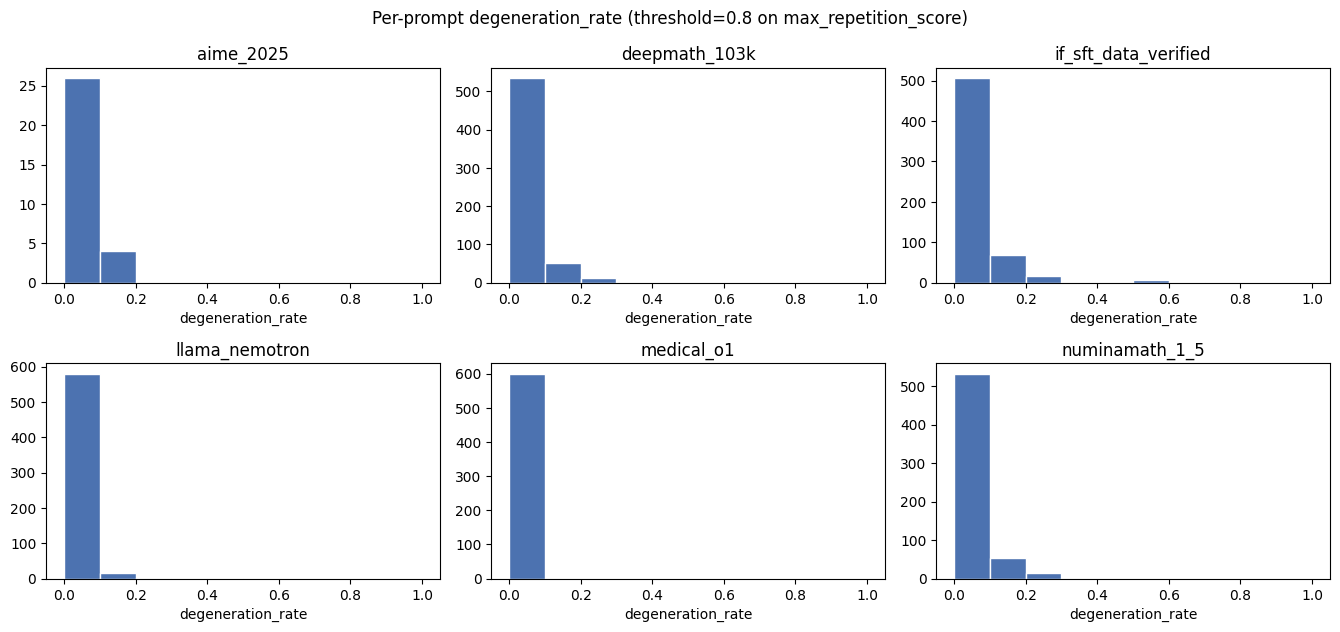

In [11]:
def _hist_grid(values_by_domain, title, xlabel, bins=np.linspace(0, 1, 11)):
    domains_present = list(values_by_domain.keys())
    n = len(domains_present)
    if n == 0:
        print("No domains available yet.")
        return
    ncols = min(3, n)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows), squeeze=False)
    for ax, domain in zip(axes.flat, domains_present):
        ax.hist(values_by_domain[domain].dropna(), bins=bins, color="#4C72B0", edgecolor="white")
        ax.set_title(domain)
        ax.set_xlabel(xlabel)
    for ax in axes.flat[n:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# --- repetition: prompt-level degeneration_rate (thresholded, from prompt_stats.parquet) ---
if not prompt_stats_df.empty:
    degeneration_summary = (
        prompt_stats_df.groupby("domain")["degeneration_rate"]
        .agg(mean_degeneration_rate="mean", max_degeneration_rate="max", n_prompts="count")
    )
    display(degeneration_summary)
    _hist_grid(
        {d: prompt_stats_df.loc[prompt_stats_df["domain"] == d, "degeneration_rate"] for d in degeneration_summary.index},
        f"Per-prompt degeneration_rate (threshold={label_module.DEFAULT_DEGENERATION_THRESHOLD} on max_repetition_score)",
        "degeneration_rate",
    )
else:
    print("prompt_stats.parquet not available yet.")

,mean,max,min
domain,,,
aime_2025,0.090909,0.500000,0.023438
deepmath_103k,0.102590,0.500000,0.019531
if_sft_data_verified,0.107388,0.500000,0.011719
llama_nemotron,0.071030,0.500000,0.011719
medical_o1,0.038220,0.367188,0.011719
numinamath_1_5,0.094971,0.500000,0.015625


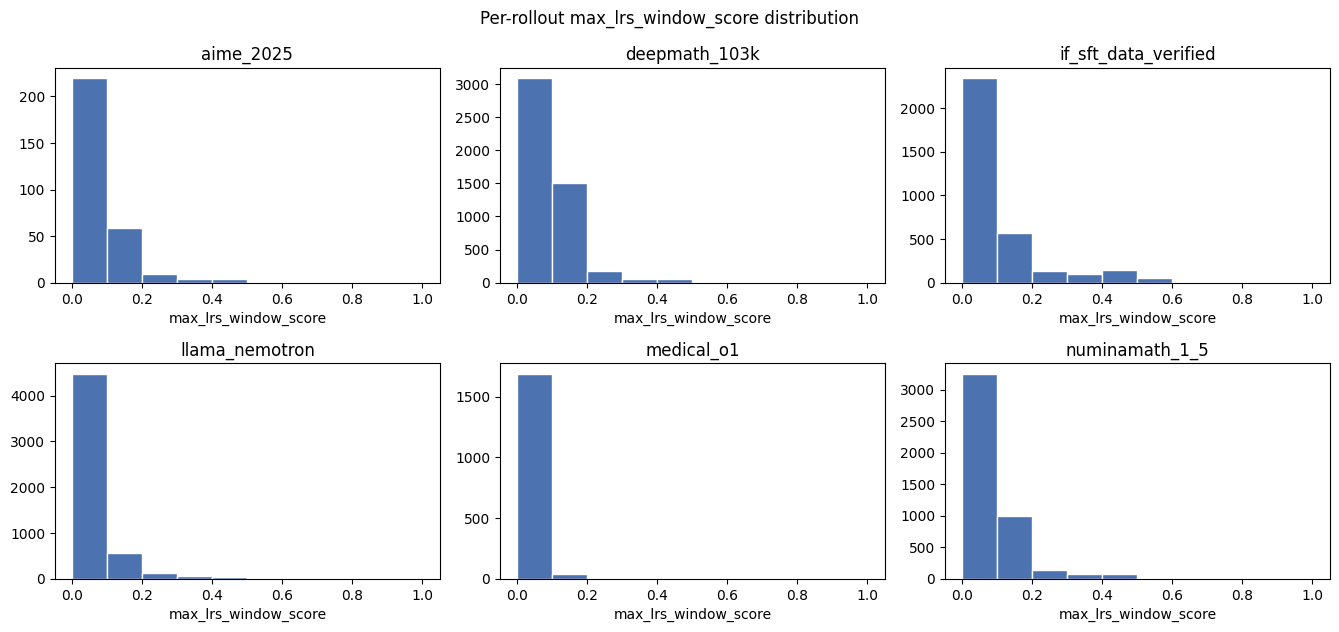

In [12]:
# --- LRS: per-rollout max_lrs_window_score distribution (no fixed threshold) ---
if not rollout_signal_df.empty:
    lrs_summary = (
        rollout_signal_df.groupby("domain")["max_lrs_window_score"]
        .agg(mean="mean", max="max", min="min")
    )
    display(lrs_summary)
    _hist_grid(
        {d: rollout_signal_df.loc[rollout_signal_df["domain"] == d, "max_lrs_window_score"] for d in lrs_summary.index},
        "Per-rollout max_lrs_window_score distribution",
        "max_lrs_window_score",
    )
else:
    print("No labeled domains available yet.")

,mean,max,min
domain,,,
aime_2025,0.427700,0.966822,0.016300
deepmath_103k,0.414214,1.317496,0.012662
if_sft_data_verified,0.617717,4.593693,0.004877
llama_nemotron,0.435042,1.097740,0.006070
medical_o1,0.818040,1.641292,0.073178
numinamath_1_5,0.373331,1.347791,0.006872


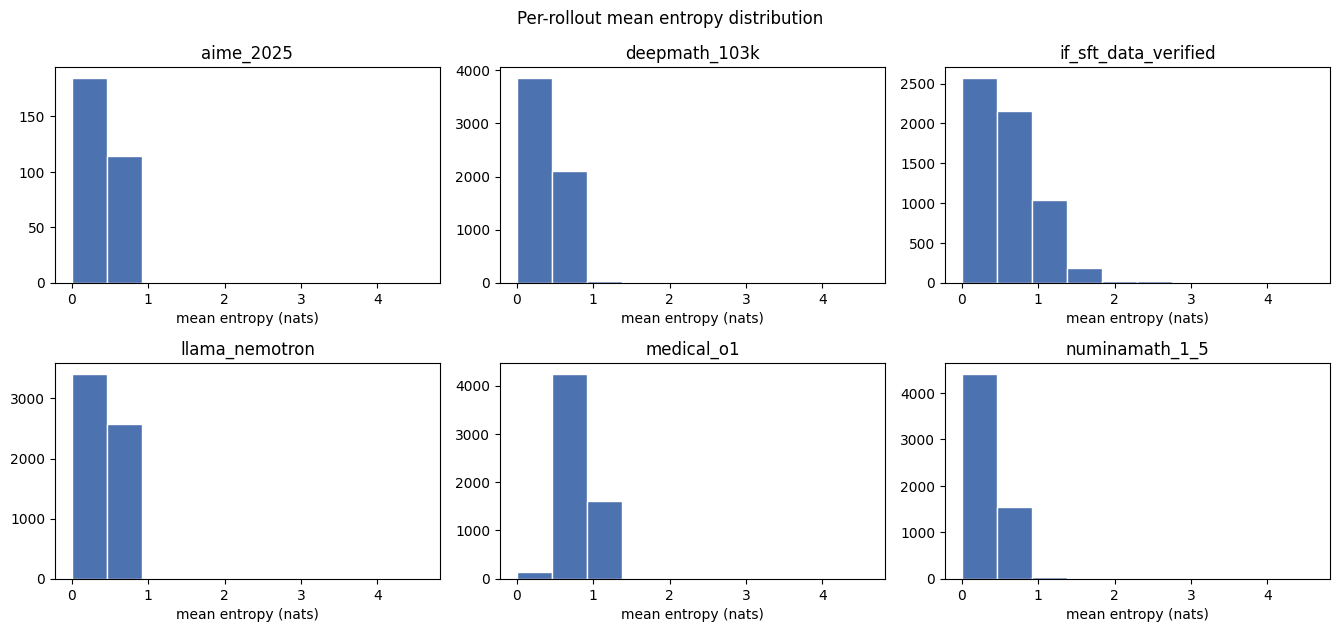

In [13]:
# --- Entropy: per-rollout mean entropy distribution ---
if not rollout_signal_df.empty:
    entropy_summary = (
        rollout_signal_df.groupby("domain")["mean_entropy"]
        .agg(mean="mean", max="max", min="min")
    )
    display(entropy_summary)
    entropy_vals = rollout_signal_df["mean_entropy"]
    entropy_bins = np.linspace(entropy_vals.min(), entropy_vals.max(), 11)
    _hist_grid(
        {d: rollout_signal_df.loc[rollout_signal_df["domain"] == d, "mean_entropy"] for d in entropy_summary.index},
        "Per-rollout mean entropy distribution",
        "mean entropy (nats)",
        bins=entropy_bins,
    )
else:
    print("No labeled domains available yet.")

In [14]:
# --- length-cap rate: fraction of rollouts that hit max_new_tokens without EOS ---
if not generations_df.empty:
    length_cap_summary = (
        generations_df.assign(hit_cap=generations_df["stop_reason"] == "length")
        .groupby("domain")["hit_cap"]
        .mean()
        .rename("length_cap_rate")
    )
    display(length_cap_summary)
else:
    print("No generated domains available yet.")

domain
aime_2025               0.033333
deepmath_103k           0.026833
if_sft_data_verified    0.060667
llama_nemotron          0.020500
medical_o1              0.000167
numinamath_1_5          0.034333
Name: length_cap_rate, dtype: float64

## 7. Interactive prompt/rollout explorer

Pick a **domain**, then a **prompt_id** within it, to see per-rollout stats
(how many of its 10 rollouts are TTR-degenerate, LRS/entropy ranges, etc.).
Then pick a **rollout_idx** and click **Render generation text** to render
the prompt + generated text to an image, shown inline here and saved as both
`.png` (for quick viewing) and `.pdf` (for reports/papers) under
`notebooks/figures/<domain>/<prompt_id>/rollout_<idx>.{png,pdf}`.

In [15]:
import ipywidgets as widgets

FIGURES_DIR = REPO_ROOT / "notebooks" / "figures"


def render_generation_figure(domain, prompt_id, rollout_idx, wrap_width=110, fontsize=8.5):
    prompt_row = prompts_df.loc[prompts_df["prompt_id"] == prompt_id].iloc[0]
    gen_row = generations_df.loc[
        (generations_df["prompt_id"] == prompt_id) & (generations_df["rollout_idx"] == rollout_idx)
    ].iloc[0]

    prompt_lines = textwrap.wrap(prompt_row["prompt_text"], width=wrap_width) or [""]
    gen_lines = textwrap.wrap(gen_row["generated_text"], width=wrap_width) or [""]

    header_lines = [
        f"{prompt_id}  /  rollout_idx={rollout_idx}  /  domain={domain}",
        f"stop_reason={gen_row['stop_reason']}   num_tokens={int(gen_row['num_tokens'])}",
    ]
    section_labels = {"PROMPT:", "GENERATED TEXT:"}
    all_lines = header_lines + [""] + ["PROMPT:"] + prompt_lines + [""] + ["GENERATED TEXT:"] + gen_lines

    line_height = 0.16  # inches per line, monospace font
    fig_height = max(2.0, len(all_lines) * line_height + 0.6)
    fig_width = 10.0

    # Prompt/generated text often contains literal "$...$" (e.g. AIME problem
    # statements) -- disable mathtext parsing so it renders as plain text
    # instead of matplotlib trying (and failing) to parse it as LaTeX math.
    with plt.rc_context({"text.parse_math": False}):
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        ax.axis("off")
        dy = 1.0 / (len(all_lines) + 2)
        for i, line in enumerate(all_lines):
            is_header = line in header_lines or line in section_labels
            ax.text(
                0.01, 1.0 - (i + 1) * dy, line,
                family="monospace", fontsize=fontsize,
                weight="bold" if is_header else "normal",
                va="top", transform=ax.transAxes,
            )
        plt.tight_layout()

    out_dir = FIGURES_DIR / domain / prompt_id
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f"rollout_{rollout_idx}.png"
    pdf_path = out_dir / f"rollout_{rollout_idx}.pdf"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return fig, png_path, pdf_path

In [16]:
domain_options = sorted(rollout_signal_df["domain"].unique()) if not rollout_signal_df.empty else []

domain_dd = widgets.Dropdown(options=domain_options, description="domain:")
prompt_dd = widgets.Dropdown(options=[], description="prompt_id:")
rollout_dd = widgets.Dropdown(options=[], description="rollout_idx:")
render_btn = widgets.Button(description="Render generation text", button_style="primary")
stats_out = widgets.Output()
render_out = widgets.Output()

THRESHOLD = label_module.DEFAULT_DEGENERATION_THRESHOLD


def _prompt_option_label(prompt_id, sub):
    n_degen = int((sub["max_repetition_score"] > THRESHOLD).sum())
    return f"{prompt_id}  ({n_degen}/{len(sub)} repetition-degenerate)"


def update_prompts(*_):
    domain = domain_dd.value
    sub = rollout_signal_df[rollout_signal_df["domain"] == domain]
    prompt_ids = sorted(sub["prompt_id"].unique())
    prompt_dd.options = [
        (_prompt_option_label(pid, sub[sub["prompt_id"] == pid]), pid) for pid in prompt_ids
    ]


def update_stats(*_):
    stats_out.clear_output()
    render_out.clear_output()
    prompt_id = prompt_dd.value
    if prompt_id is None:
        rollout_dd.options = []
        return
    sub = rollout_signal_df[rollout_signal_df["prompt_id"] == prompt_id].sort_values("rollout_idx")
    rollout_dd.options = sub["rollout_idx"].tolist()
    with stats_out:
        n = len(sub)
        n_repetition_degen = int((sub["max_repetition_score"] > THRESHOLD).sum())
        print(f"{prompt_id}  (domain={domain_dd.value}, {n} rollouts)")
        print(f"  repetition-degenerate (max_repetition_score > {THRESHOLD}): {n_repetition_degen}/{n}")
        print(f"  max_lrs_window_score range : {sub['max_lrs_window_score'].min():.3f} - {sub['max_lrs_window_score'].max():.3f}")
        print(f"  mean_entropy range         : {sub['mean_entropy'].min():.3f} - {sub['mean_entropy'].max():.3f}")
        print()
        display_df = sub[[
            "rollout_idx", "num_tokens", "stop_reason",
            "max_repetition_score", "max_lrs_window_score", "mean_entropy",
        ]].assign(repetition_degenerate=lambda d: d["max_repetition_score"] > THRESHOLD).set_index("rollout_idx")
        display(display_df)


def on_render_click(_):
    render_out.clear_output()
    domain = domain_dd.value
    prompt_id = prompt_dd.value
    rollout_idx = rollout_dd.value
    if rollout_idx is None:
        with render_out:
            print("Select a rollout_idx first.")
        return
    fig, png_path, pdf_path = render_generation_figure(domain, prompt_id, rollout_idx)
    with render_out:
        plt.show()
        print(f"Saved PNG: {png_path}")
        print(f"Saved PDF: {pdf_path}")
    plt.close(fig)


domain_dd.observe(update_prompts, names="value")
prompt_dd.observe(update_stats, names="value")
render_btn.on_click(on_render_click)

if domain_options:
    update_prompts()

display(widgets.VBox([
    widgets.HBox([domain_dd, prompt_dd, rollout_dd]),
    stats_out,
    render_btn,
    render_out,
]))